In [ ]:
# Install library yang dibutuhkan
!pip install scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

# Load dataset
df = pd.read_excel("E Commerce Dataset.xlsx", sheet_name="E Comm")

print("✅ Dataset berhasil diload!")
print("Shape:", df.shape)
print("\nKolom-kolom:")
print(df.columns.tolist())
df.head()

✅ Dataset berhasil diload!
Shape: (5630, 20)

Kolom-kolom:
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


**Exploratory Data Analysis (EDA)**

In [ ]:
# Info dasar dataset
print("="*50)
print("SHAPE:", df.shape)
print("="*50)

print("\n📌 5 Baris Pertama:")
display(df.head())

print("\n📌 Info Dataset:")
df.info()

print("\n📌 Statistik Deskriptif:")
display(df.describe())

SHAPE: (5630, 20)

📌 5 Baris Pertama:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60



📌 Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  N

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


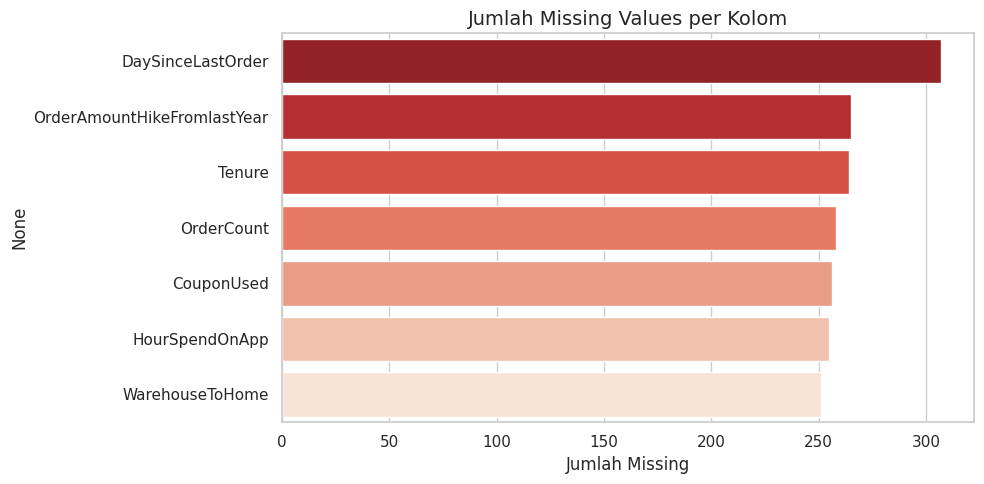


Persentase Missing Values:
DaySinceLastOrder              5.45
OrderAmountHikeFromlastYear    4.71
Tenure                         4.69
OrderCount                     4.58
CouponUsed                     4.55
HourSpendOnApp                 4.53
WarehouseToHome                4.46
dtype: float64


In [ ]:
# Visualisasi missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")
plt.title("Jumlah Missing Values per Kolom", fontsize=14)
plt.xlabel("Jumlah Missing")
plt.tight_layout()
plt.savefig("missing_values.png")
plt.show()

print("\nPersentase Missing Values:")
print((missing / len(df) * 100).round(2))

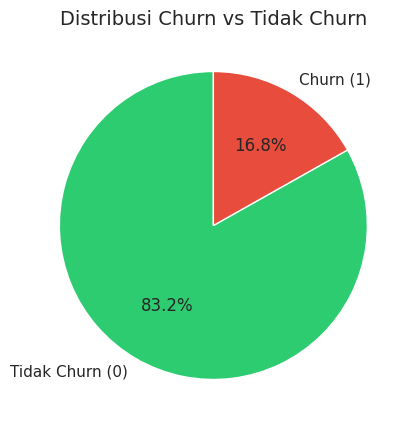


Total Churn    : 948 (16.8%)
Total Tdk Churn: 4682 (83.2%)


In [ ]:
plt.figure(figsize=(8, 5))

churn_counts = df['Churn'].value_counts()
labels = ['Tidak Churn (0)', 'Churn (1)']
colors = ['#2ecc71', '#e74c3c']

plt.pie(churn_counts, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title("Distribusi Churn vs Tidak Churn", fontsize=14)
plt.savefig("churn_distribution.png")
plt.show()

print(f"\nTotal Churn    : {churn_counts[1]} ({churn_counts[1]/len(df)*100:.1f}%)")
print(f"Total Tdk Churn: {churn_counts[0]} ({churn_counts[0]/len(df)*100:.1f}%)")

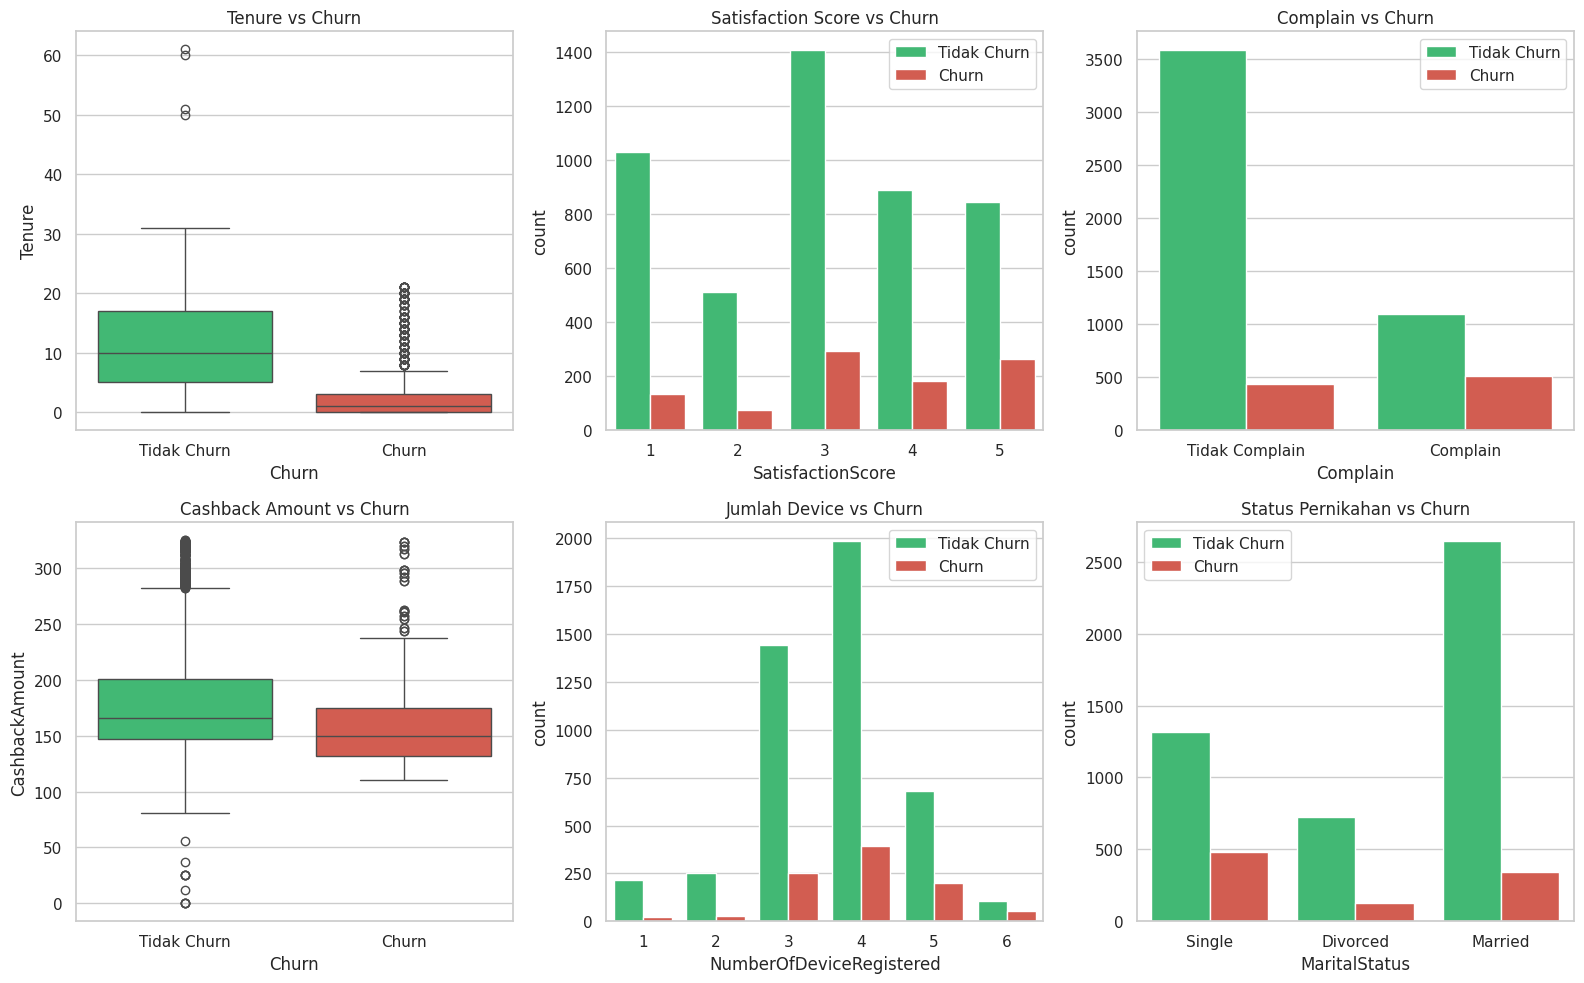

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Tenure vs Churn
sns.boxplot(x='Churn', y='Tenure', data=df, ax=axes[0,0], palette=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Tenure vs Churn')
axes[0,0].set_xticklabels(['Tidak Churn', 'Churn'])

# 2. SatisfactionScore vs Churn
sns.countplot(x='SatisfactionScore', hue='Churn', data=df, ax=axes[0,1], palette=['#2ecc71','#e74c3c'])
axes[0,1].set_title('Satisfaction Score vs Churn')
axes[0,1].legend(['Tidak Churn', 'Churn'])

# 3. Complain vs Churn
sns.countplot(x='Complain', hue='Churn', data=df, ax=axes[0,2], palette=['#2ecc71','#e74c3c'])
axes[0,2].set_title('Complain vs Churn')
axes[0,2].set_xticklabels(['Tidak Complain', 'Complain'])
axes[0,2].legend(['Tidak Churn', 'Churn'])

# 4. CashbackAmount vs Churn
sns.boxplot(x='Churn', y='CashbackAmount', data=df, ax=axes[1,0], palette=['#2ecc71','#e74c3c'])
axes[1,0].set_title('Cashback Amount vs Churn')
axes[1,0].set_xticklabels(['Tidak Churn', 'Churn'])

# 5. NumberOfDeviceRegistered vs Churn
sns.countplot(x='NumberOfDeviceRegistered', hue='Churn', data=df, ax=axes[1,1], palette=['#2ecc71','#e74c3c'])
axes[1,1].set_title('Jumlah Device vs Churn')
axes[1,1].legend(['Tidak Churn', 'Churn'])

# 6. MaritalStatus vs Churn
sns.countplot(x='MaritalStatus', hue='Churn', data=df, ax=axes[1,2], palette=['#2ecc71','#e74c3c'])
axes[1,2].set_title('Status Pernikahan vs Churn')
axes[1,2].legend(['Tidak Churn', 'Churn'])

plt.tight_layout()
plt.savefig("eda_churn_analysis.png")
plt.show()

**Data Cleaning**

In [ ]:
# ============================================
# STEP 3: DATA CLEANING
# ============================================

print("Shape sebelum cleaning:", df.shape)

# 3.1 — Hapus kolom CustomerID (tidak berguna untuk prediksi)
df = df.drop(columns=['CustomerID'])

# 3.2 — Isi Missing Values dengan MEDIAN
# Kenapa median? Karena lebih robust terhadap outlier
kolom_numerik_missing = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                          'OrderAmountHikeFromlastYear', 'CouponUsed',
                          'OrderCount', 'DaySinceLastOrder']

for kolom in kolom_numerik_missing:
    median_val = df[kolom].median()
    df[kolom].fillna(median_val, inplace=True)
    print(f"✅ {kolom}: diisi dengan median = {median_val}")

# 3.3 — Verifikasi: tidak ada missing values lagi
print("\n📌 Missing values setelah cleaning:")
print(df.isnull().sum())

print("\n✅ Data Cleaning selesai!")
print("Shape setelah cleaning:", df.shape)

Shape sebelum cleaning: (5630, 20)
✅ Tenure: diisi dengan median = 9.0
✅ WarehouseToHome: diisi dengan median = 14.0
✅ HourSpendOnApp: diisi dengan median = 3.0
✅ OrderAmountHikeFromlastYear: diisi dengan median = 15.0
✅ CouponUsed: diisi dengan median = 1.0
✅ OrderCount: diisi dengan median = 2.0
✅ DaySinceLastOrder: diisi dengan median = 3.0

📌 Missing values setelah cleaning:
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount          

In [ ]:
# ============================================
# STEP 4: FEATURE ENGINEERING
# ============================================

from sklearn.preprocessing import LabelEncoder

# 4.1 — Cek kolom kategorikal
# Fix: hapus 'str', cukup pakai 'object'
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()
print("Kolom kategorikal:", kolom_kategorikal)

# Cek nilai unik tiap kolom
for kolom in kolom_kategorikal:
    print(f"\n{kolom}: {df[kolom].unique()}")

Kolom kategorikal: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

PreferredLoginDevice: ['Mobile Phone' 'Phone' 'Computer']

PreferredPaymentMode: ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender: ['Female' 'Male']

PreferedOrderCat: ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

MaritalStatus: ['Single' 'Divorced' 'Married']


**Fix Inconsistency + Label Encoding**

In [ ]:
# 4.2 — Fix Data Inconsistency dulu
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Phone', 'Mobile Phone')
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({'COD': 'Cash on Delivery',
                                                                  'CC': 'Credit Card'})
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile Phone', 'Mobile')

# Verifikasi sudah bersih
print("Setelah fix:")
print("PreferredLoginDevice :", df['PreferredLoginDevice'].unique())
print("PreferredPaymentMode :", df['PreferredPaymentMode'].unique())
print("PreferedOrderCat     :", df['PreferedOrderCat'].unique())

# 4.3 — Label Encoding
le = LabelEncoder()

for kolom in kolom_kategorikal:
    df[kolom] = le.fit_transform(df[kolom])
    print(f"✅ {kolom} → encoded")

print("\n📌 Sample data setelah encoding:")
display(df.head())

print("\n📌 Data types sekarang:")
print(df.dtypes)

Setelah fix:
PreferredLoginDevice : ['Mobile Phone' 'Computer']
PreferredPaymentMode : ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet']
PreferedOrderCat     : ['Laptop & Accessory' 'Mobile' 'Others' 'Fashion' 'Grocery']
✅ PreferredLoginDevice → encoded
✅ PreferredPaymentMode → encoded
✅ Gender → encoded
✅ PreferedOrderCat → encoded
✅ MaritalStatus → encoded

📌 Sample data setelah encoding:


,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,1,3,6.0,2,0,3.0,3,2,2,2,9,1,11.0,1.0,1.0,5.0,159.93
1,1,9.0,1,1,8.0,4,1,3.0,4,3,3,2,7,1,15.0,0.0,1.0,0.0,120.90
2,1,9.0,1,1,30.0,2,1,2.0,4,3,3,2,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,1,3,15.0,2,1,2.0,4,2,5,2,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,1,1,12.0,1,1,3.0,3,3,5,2,3,0,11.0,1.0,1.0,3.0,129.60



📌 Data types sekarang:
Churn                            int64
Tenure                         float64
PreferredLoginDevice             int64
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode             int64
Gender                           int64
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                 int64
SatisfactionScore                int64
MaritalStatus                    int64
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object


**Build Machine Learning Model**

In [ ]:
# ============================================
# STEP 5: BUILD MODEL
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)

# 5.1 — Pisahkan Feature (X) dan Target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Shape X (features):", X.shape)
print("Shape y (target)  :", y.shape)
print("\nDistribusi target:")
print(y.value_counts())

# 5.2 — Split Train & Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% untuk testing
    random_state=42,    # agar hasilnya konsisten
    stratify=y          # pastikan proporsi churn sama di train & test
)

print(f"\n✅ Train set: {X_train.shape[0]} baris")
print(f"✅ Test set : {X_test.shape[0]} baris")

# 5.3 — Scaling (normalisasi angka agar setara)
# Kenapa perlu? Tenure (0-60) vs CityTier (1-3) → range berbeda
# Logistic Regression sensitif terhadap perbedaan skala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Scaling selesai!")

Shape X (features): (5630, 18)
Shape y (target)  : (5630,)

Distribusi target:
Churn
0    4682
1     948
Name: count, dtype: int64

✅ Train set: 4504 baris
✅ Test set : 1126 baris

✅ Scaling selesai!


In [ ]:
# 5.4 — MODEL 1: Logistic Regression
print("="*50)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*50)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Tidak Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# 5.5 — MODEL 2: Random Forest
print("\n" + "="*50)
print("MODEL 2: RANDOM FOREST")
print("="*50)

rf = RandomForestClassifier(class_weight='balanced',
                             n_estimators=100,
                             random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Tidak Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

MODEL 1: LOGISTIC REGRESSION

📌 Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.95      0.76      0.85       936
       Churn       0.41      0.81      0.54       190

    accuracy                           0.77      1126
   macro avg       0.68      0.78      0.69      1126
weighted avg       0.86      0.77      0.79      1126

ROC-AUC Score: 0.8557

MODEL 2: RANDOM FOREST

📌 Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.98      1.00      0.99       936
       Churn       0.98      0.92      0.95       190

    accuracy                           0.98      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126

ROC-AUC Score: 0.9990


**Visualisasi Evaluasi Model**

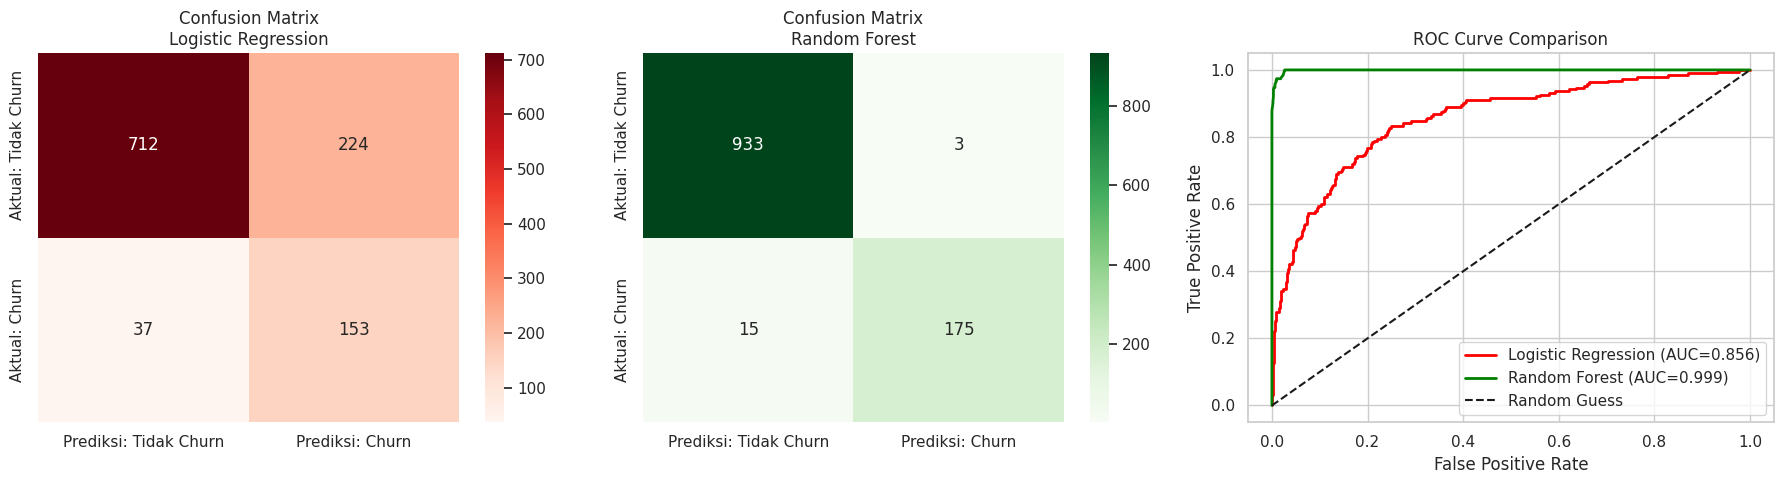

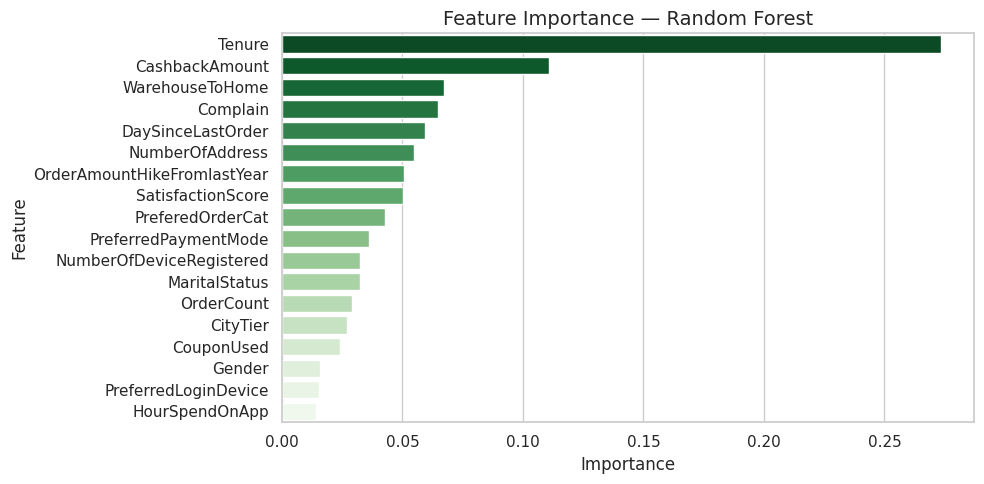

Top 5 Fitur Terpenting:
              Feature  Importance
0              Tenure    0.273508
17     CashbackAmount    0.110996
3     WarehouseToHome    0.067164
12           Complain    0.064905
16  DaySinceLastOrder    0.059449


In [18]:
# ============================================
# STEP 6: VISUALISASI EVALUASI
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 6.1 — Confusion Matrix: Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Prediksi: Tidak Churn', 'Prediksi: Churn'],
            yticklabels=['Aktual: Tidak Churn', 'Aktual: Churn'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix\nLogistic Regression', fontsize=12)

# 6.2 — Confusion Matrix: Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prediksi: Tidak Churn', 'Prediksi: Churn'],
            yticklabels=['Aktual: Tidak Churn', 'Aktual: Churn'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix\nRandom Forest', fontsize=12)

# 6.3 — ROC Curve: Kedua Model
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[2].plot(fpr_lr, tpr_lr,
             label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})',
             color='red', linewidth=2)
axes[2].plot(fpr_rf, tpr_rf,
             label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})',
             color='green', linewidth=2)
axes[2].plot([0,1], [0,1], 'k--', label='Random Guess')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison', fontsize=12)
axes[2].legend()

plt.tight_layout()
plt.savefig("model_evaluation.png")
plt.show()

# 6.4 — Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance, palette='Greens_r')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

print("Top 5 Fitur Terpenting:")
print(feature_importance.head())

**Business Insights & Rekomendasi**

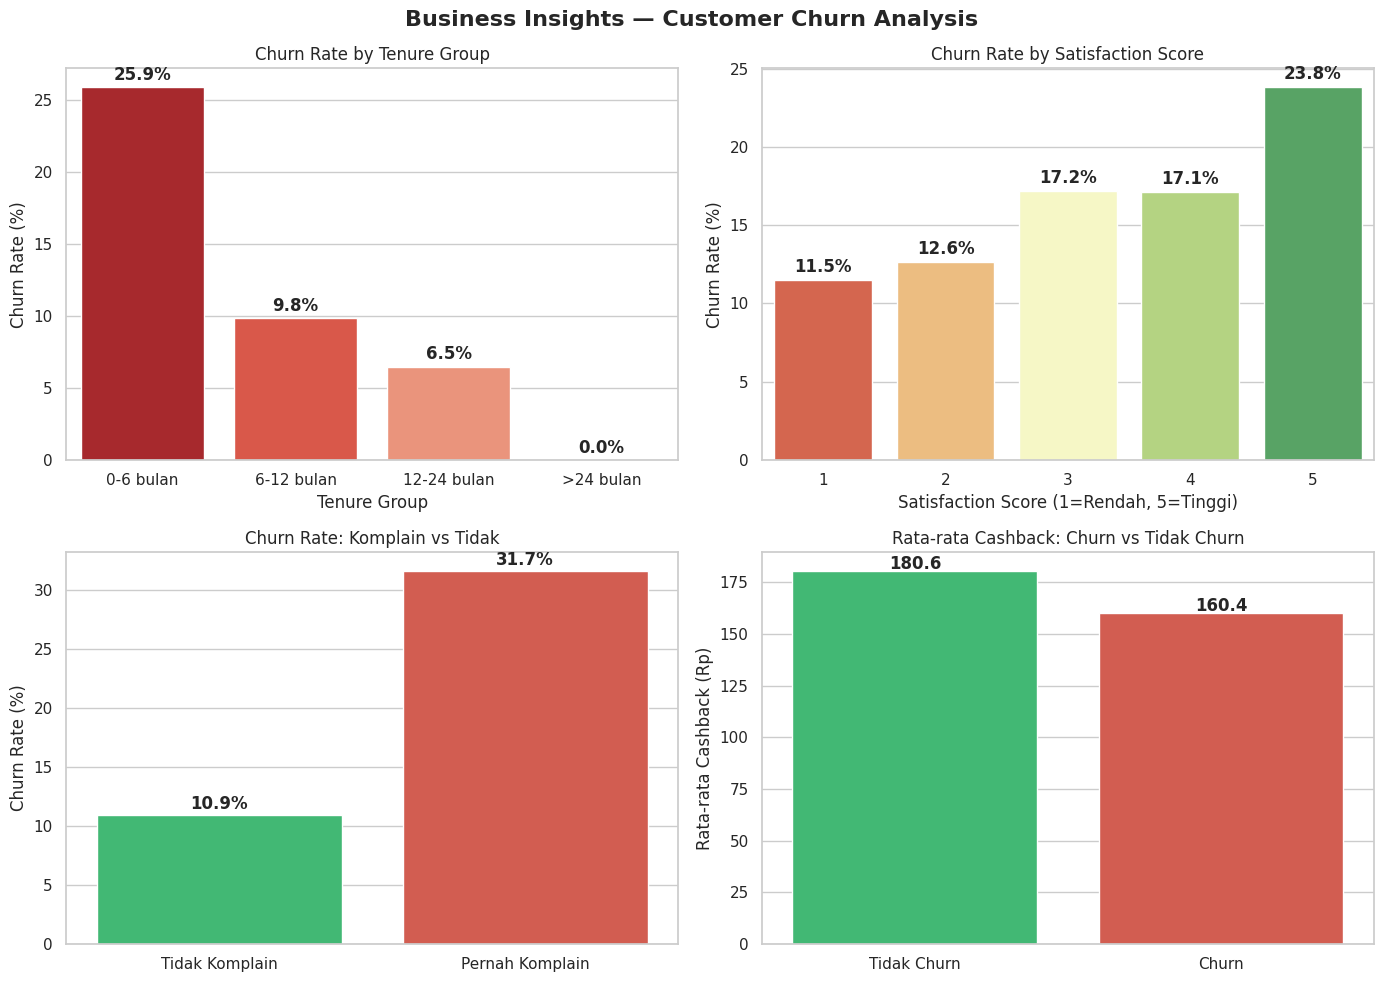

📊 BUSINESS INSIGHTS SUMMARY

1. Churn Rate keseluruhan: 16.8%

2. Churn Rate by Tenure:
      0-6 bulan: 25.9%
     6-12 bulan: 9.8%
    12-24 bulan: 6.5%
      >24 bulan: 0.0%

3. Churn Rate Komplain vs Tidak:
   Tidak Komplain: 10.9%
   Pernah Komplain: 31.7%

4. Rata-rata Cashback:
   Tidak Churn: 180.6
   Churn      : 160.4


In [19]:
# ============================================
# STEP 7: BUSINESS INSIGHTS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Business Insights — Customer Churn Analysis',
             fontsize=16, fontweight='bold')

# 7.1 — Churn Rate by Tenure Group
df['TenureGroup'] = pd.cut(df['Tenure'],
                            bins=[0, 6, 12, 24, 60],
                            labels=['0-6 bulan', '6-12 bulan',
                                    '12-24 bulan', '>24 bulan'])

churn_by_tenure = df.groupby('TenureGroup', observed=True)['Churn'].mean() * 100

sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure.values,
            palette='Reds_r', ax=axes[0,0])
axes[0,0].set_title('Churn Rate by Tenure Group')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].set_xlabel('Tenure Group')
for i, v in enumerate(churn_by_tenure.values):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 7.2 — Churn Rate by Satisfaction Score
churn_by_satisfaction = df.groupby('SatisfactionScore')['Churn'].mean() * 100

sns.barplot(x=churn_by_satisfaction.index,
            y=churn_by_satisfaction.values,
            palette='RdYlGn', ax=axes[0,1])
axes[0,1].set_title('Churn Rate by Satisfaction Score')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].set_xlabel('Satisfaction Score (1=Rendah, 5=Tinggi)')
for i, v in enumerate(churn_by_satisfaction.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 7.3 — Churn Rate by Complain
churn_by_complain = df.groupby('Complain')['Churn'].mean() * 100

sns.barplot(x=['Tidak Komplain', 'Pernah Komplain'],
            y=churn_by_complain.values,
            palette=['#2ecc71', '#e74c3c'], ax=axes[1,0])
axes[1,0].set_title('Churn Rate: Komplain vs Tidak')
axes[1,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(churn_by_complain.values):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 7.4 — Average Cashback: Churn vs Tidak
cashback_by_churn = df.groupby('Churn')['CashbackAmount'].mean()

sns.barplot(x=['Tidak Churn', 'Churn'],
            y=cashback_by_churn.values,
            palette=['#2ecc71', '#e74c3c'], ax=axes[1,1])
axes[1,1].set_title('Rata-rata Cashback: Churn vs Tidak Churn')
axes[1,1].set_ylabel('Rata-rata Cashback (Rp)')
for i, v in enumerate(cashback_by_churn.values):
    axes[1,1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("business_insights.png")
plt.show()

# Print summary numbers
print("="*55)
print("📊 BUSINESS INSIGHTS SUMMARY")
print("="*55)
print(f"\n1. Churn Rate keseluruhan: {df['Churn'].mean()*100:.1f}%")
print(f"\n2. Churn Rate by Tenure:")
for group, rate in churn_by_tenure.items():
    print(f"   {group:>12}: {rate:.1f}%")
print(f"\n3. Churn Rate Komplain vs Tidak:")
print(f"   Tidak Komplain: {churn_by_complain.iloc[0]:.1f}%")
print(f"   Pernah Komplain: {churn_by_complain.iloc[1]:.1f}%")
print(f"\n4. Rata-rata Cashback:")
print(f"   Tidak Churn: {cashback_by_churn.iloc[0]:.1f}")
print(f"   Churn      : {cashback_by_churn.iloc[1]:.1f}")